In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
pcsv = pd.read_csv('python_final.csv')
rcsv = pd.read_csv('rust_final.csv')


pcsv['nprobe'] = pcsv['params'].str.extract(r'nprobe=(\d+)').astype(int)
rcsv['nprobe'] = rcsv['params'].str.extract(r'nprobe=(\d+)').astype(int)

rcsv['task'] = rcsv['params'].str.extract(r'rust-lmi-task=(\w+)')
pcsv['task'] = pcsv['params'].str.extract(r't(\d+)')

/tmp/ipykernel_3196581/1996688667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcsv_task1['memuse'] = '191GB'
/tmp/ipykernel_3196581/1996688667.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcsv_task1['memuse'] = '217GB'


Task 1 Performance Comparison: Python vs Rust
                              Python                  Rust
kmeanstime      19 minutes 2 seconds  9 minutes 38 seconds
trainmodeltime  11 minutes 3 seconds   9 minutes 9 seconds
buildtime       64 minutes 7 seconds  67 minutes 8 seconds
querytime       9 minutes 10 seconds            17 seconds
recall                      0.899552               0.89976
memuse                         191GB                 217GB


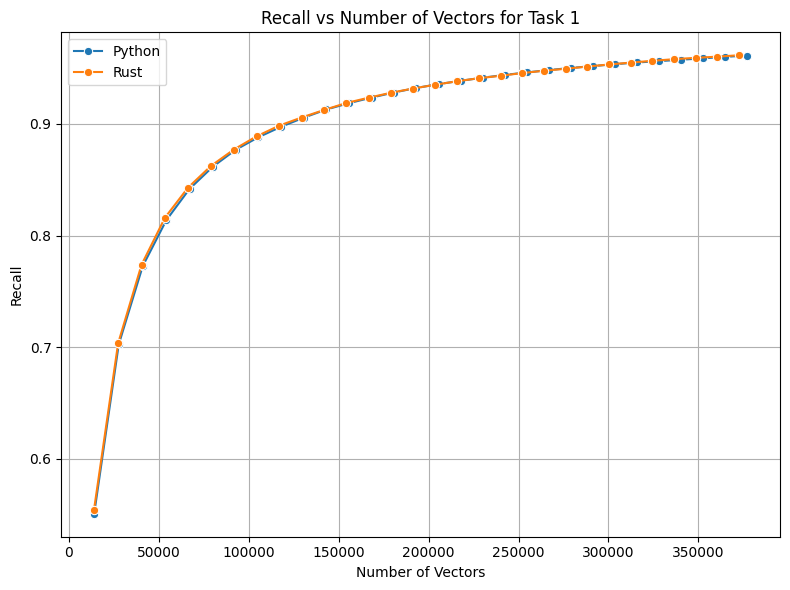

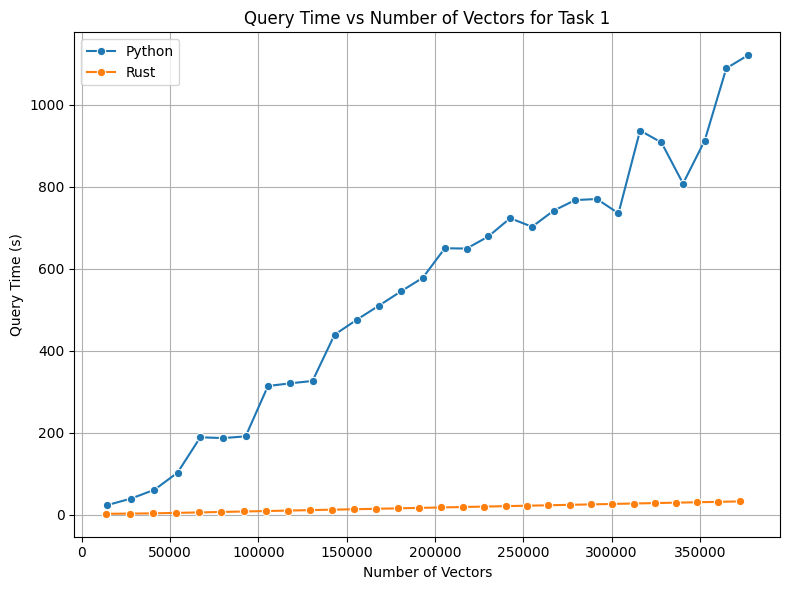

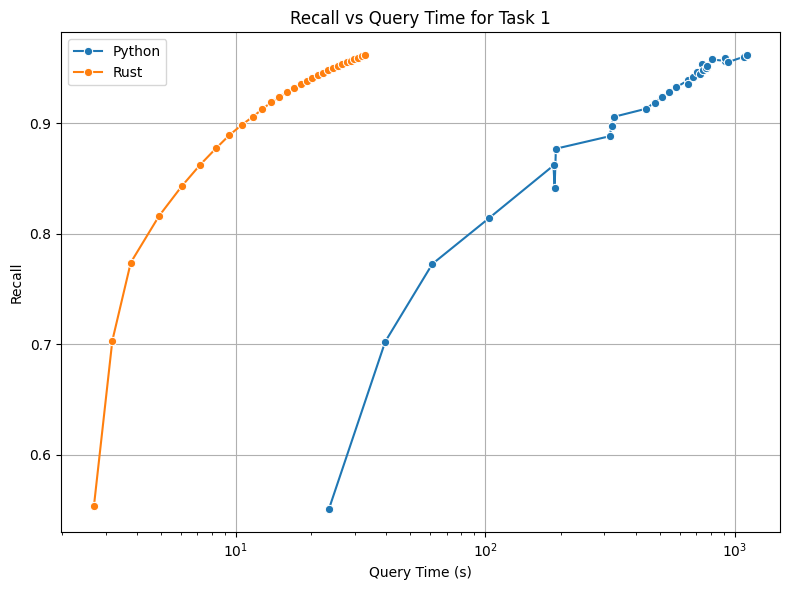

In [19]:
pcsv_task1 = pcsv[(pcsv['task'] == '1') & (pcsv['size'] == '100M')]
pcsv_task1['memuse'] = '191GB'

rcsv_task1 = rcsv[(rcsv['task'] == '1') & (rcsv['size'] == '100M')]
rcsv_task1['memuse'] = '217GB'

numeric_metrics = ['kmeanstime', 'trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task1[numeric_metrics].mean()
rust_means = rcsv_task1[numeric_metrics].mean()

python_means['memuse'] = pcsv_task1['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task1['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 1 Performance Comparison: Python vs Rust")
print(comparison_df)

pcsv_task1 = pcsv[(pcsv['task'] == '1') & (pcsv['size'] == '100M')]

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 1')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task1_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 1')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task1_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time for Task 1
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 1')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task1_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3196581/1329475625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcsv_task3['memuse'] = '76GB'
/tmp/ipykernel_3196581/1329475625.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcsv_task3['memuse'] = '88GB'


Task 3 Performance Comparison: Python vs Rust
                                Python                   Rust
kmeanstime       12 minutes 39 seconds   9 minutes 18 seconds
encdatabasetime   5 minutes 12 seconds  10 minutes 39 seconds
encqueriestime               0 seconds              0 seconds
trainmodeltime    21 minutes 9 seconds   8 minutes 55 seconds
buildtime        89 minutes 37 seconds  91 minutes 38 seconds
querytime                   53 seconds              7 seconds
recall                        0.548697                0.54729
memuse                            76GB                   88GB


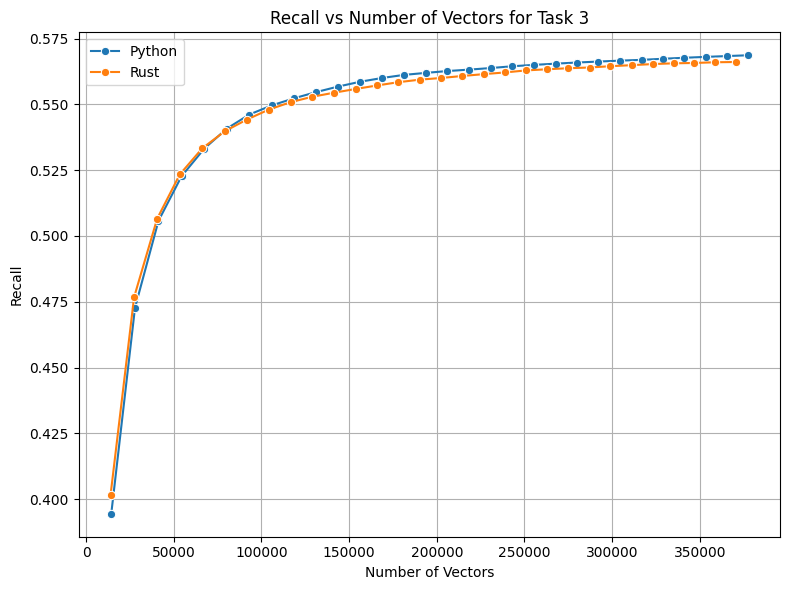

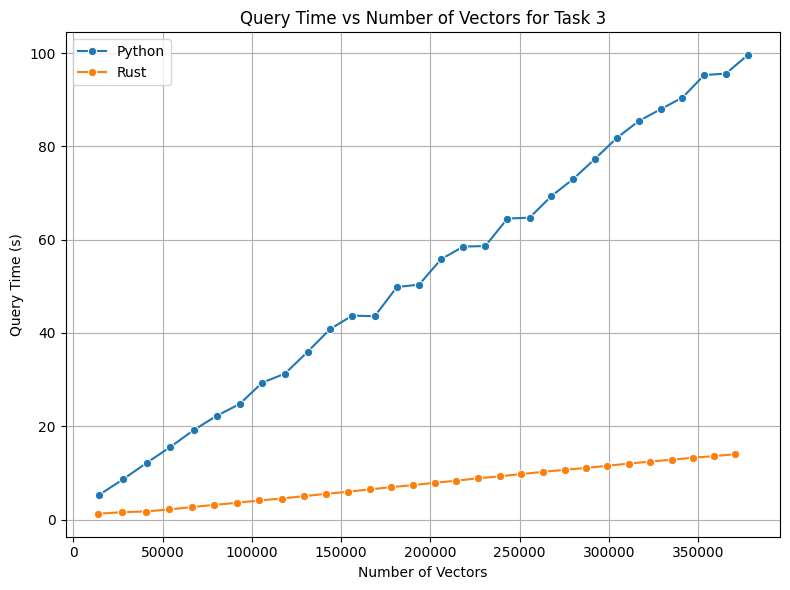

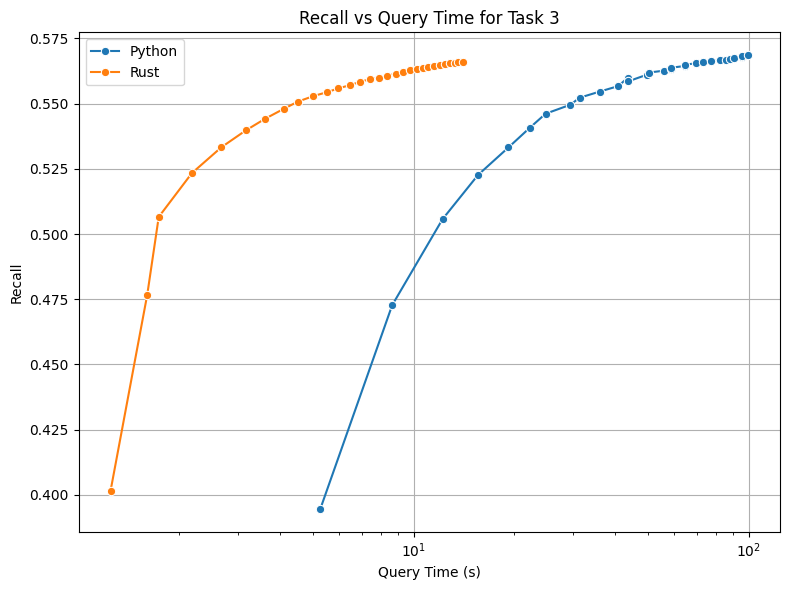

In [20]:
pcsv_task3 = pcsv[(pcsv['task'] == '3') & (pcsv['size'] == '100M')]
pcsv_task3['memuse'] = '76GB'

rcsv_task3 = rcsv[(rcsv['task'] == '3') & (rcsv['size'] == '100M')]
rcsv_task3['memuse'] = '88GB'

numeric_metrics = ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task3[numeric_metrics].mean()
rust_means = rcsv_task3[numeric_metrics].mean()

python_means['memuse'] = pcsv_task3['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task3['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 3 Performance Comparison: Python vs Rust")
print(comparison_df)

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 3')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task3_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 3')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task3_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 3')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task3_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3196581/3895413130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcsv_task2.loc[:, 'memuse'] = '35GB'
/tmp/ipykernel_3196581/3895413130.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcsv_task2['memuse'] = '35GB'


Task 3 Performance Comparison: Python vs Rust
                                 Python                    Rust
kmeanstime        11 minutes 43 seconds   73 minutes 50 seconds
encdatabasetime    5 minutes 59 seconds     7 minutes 5 seconds
encqueriestime                0 seconds               0 seconds
trainmodeltime    25 minutes 36 seconds   23 minutes 52 seconds
buildtime        111 minutes 50 seconds  217 minutes 37 seconds
querytime         42 minutes 47 seconds    39 minutes 8 seconds
recall                         0.780427                0.778425
memuse                             35GB                    35GB


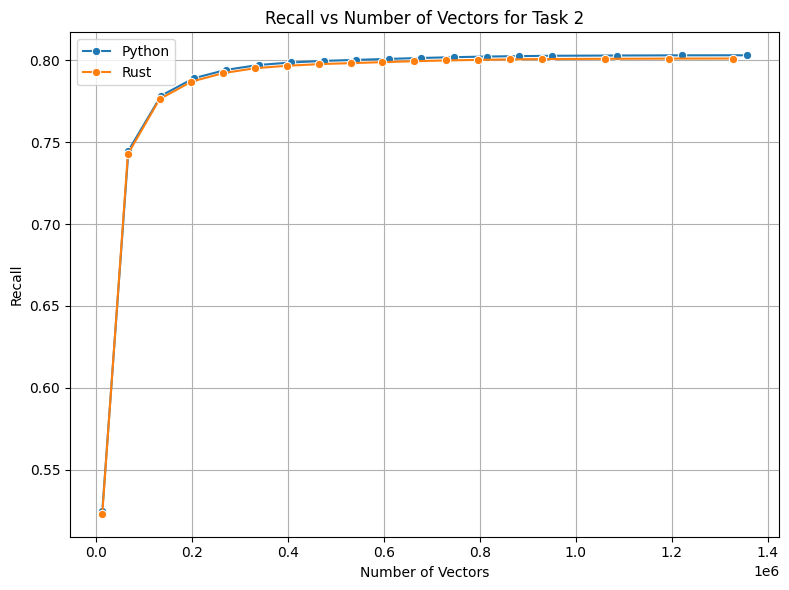

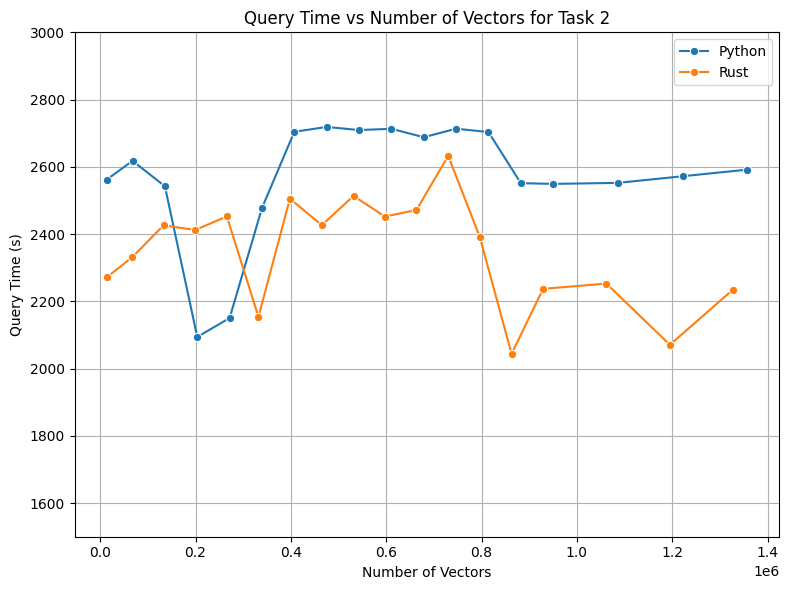

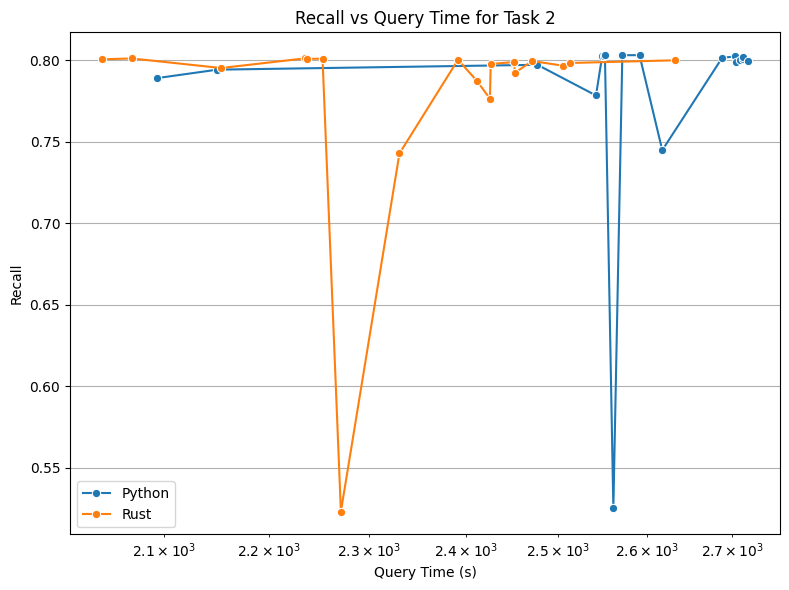

In [21]:
pcsv_task2 = pcsv[(pcsv['task'] == '2') & (pcsv['size'] == '100M')]
pcsv_task2.loc[:, 'memuse'] = '35GB'

rcsv_task2 = rcsv[(rcsv['task'] == '2') & (rcsv['size'] == '100M')]
rcsv_task2['memuse'] = '35GB'

numeric_metrics = ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task2[numeric_metrics].mean()
rust_means = rcsv_task2[numeric_metrics].mean()

python_means['memuse'] = pcsv_task2['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task2['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 3 Performance Comparison: Python vs Rust")
print(comparison_df)

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 2')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task2_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 2')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.ylim(1500, 3000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task2_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 2')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task2_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()